# Taller en clase: Regresión Lineal (con Python)

**Fundamentos para IA · NRC 94103 · Semana 7**

**Dataset de trabajo:** `StudentsPerformance.csv` (1000 registros de estudiantes).

Este taller desarrolla **en código Python** los 6 conceptos de
[`01_Regresion_lineal_conceptos_basicos.md`](01_Regresion_lineal_conceptos_basicos.md), más el ejemplo
aplicado de Levene de la sección 5 (Ejercicio 7). Ahí los viste con ejemplos y ejercicios en papel; aquí vas
a comprobarlos con `pandas`, `scipy.stats` y `statsmodels`, paso a paso, sobre las notas reales de lectura,
escritura y matemáticas de 1000 estudiantes. Trabajen en parejas o grupos pequeños.

**Configuración inicial** (ejecuta esto una sola vez, al comienzo):

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---

## Ejercicio 1 — Estadística descriptiva antes de un modelo de IA

*(Corresponde a la sección 1 de `01_...md`.)* Antes de ajustar cualquier modelo, hay que explorar los datos:
así como un profesor con experiencia primero "observa" a sus estudiantes antes de sacar conclusiones.

       reading score  writing score
count    1000.000000    1000.000000
mean       69.169000      68.054000
std        14.600192      15.195657
min        17.000000      10.000000
25%        59.000000      57.750000
50%        70.000000      69.000000
75%        79.000000      79.000000
max       100.000000     100.000000


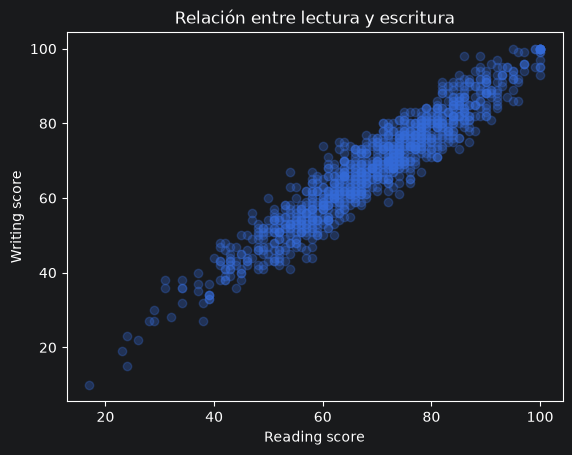

In [2]:
print(df[["reading score", "writing score"]].describe())

plt.scatter(df["reading score"], df["writing score"], alpha=0.3)
plt.xlabel("Reading score")
plt.ylabel("Writing score")
plt.title("Relación entre lectura y escritura")
plt.show()

**Preguntas:**

a) Según el `.describe()`, ¿los promedios de `reading score` y `writing score` son parecidos entre sí?
b) Mirando el diagrama de dispersión, ¿la relación entre las dos variables se ve aproximadamente lineal (una
nube de puntos que sube en línea recta) o no?
c) ¿Qué parte de este ejercicio es **estadística descriptiva**, y qué tendrías que hacer para dar el salto
hacia una conclusión **inferencial** sobre esa relación?

---

## Ejercicio 2 — Pruebas de hipótesis sobre el coeficiente (H0 y H1)

*(Corresponde a la sección 2 de `01_...md`.)* Vas a ajustar una regresión lineal simple y poner a prueba si
`reading score` realmente se relaciona con `writing score`, o si podría ser puro azar.

**Fórmula que vas a calcular con código** (el estadístico *t* del coeficiente):

$$t = \frac{b_1 - 0}{SE(b_1)}$$

`resultado.slope` es $b_1$ y `resultado.stderr` es $SE(b_1)$; `stats.linregress` ya calcula el p-value
asociado a ese *t*, pero el `____` del código te pide sacarlo tú de `resultado`.

In [3]:
x = df["reading score"]
y = df["writing score"]

resultado = stats.linregress(x, y)
print(f"pendiente (b1) = {resultado.slope:.4f}")
print(f"intercepto (b0) = {resultado.intercept:.4f}")
print(f"valor p = ____")
print(f"error estándar de b1 = {resultado.stderr:.4f}")

pendiente (b1) = 0.9935
intercepto (b0) = -0.6676
valor p = ____
error estándar de b1 = 0.0098


**Preguntas:**

a) Plantea H0 y H1 para la pendiente (`b1`) de este modelo.
b) Calcula el estadístico *t* = `b1 / error estándar`. ¿Te parece un valor grande o pequeño?
c) Con el p-value obtenido, ¿rechazas o no rechazas H0? Redacta la conclusión en una frase, conectada con la
pregunta original.

---

## Ejercicio 3 — Interpretar la ecuación de regresión

*(Corresponde a la sección 3 de `01_...md`.)* Con los coeficientes del Ejercicio 2, vas a interpretar la
ecuación `writing score = b0 + b1 * reading score` y usarla para predecir.

**Fórmula que estás usando:**

$$\hat{y} = b_0 + b_1 x$$

Es la misma recta de mínimos cuadrados ($b_1 = S_{xy}/S_{xx}$, $b_0 = \bar{y} - b_1\bar{x}$) que
`scipy.stats.linregress` calcula por dentro; aquí solo estás evaluando esa recta en `x = 80` y `x = 50`.

In [4]:
b0 = resultado.intercept
b1 = resultado.slope

pred_80 = b0 + b1 * 80
pred_50 = b0 + b1 * 50

print(f"Predicción para reading=80 -> ____")
print(f"Predicción para reading=50 -> ____")

Predicción para reading=80 -> ____
Predicción para reading=50 -> ____


**Preguntas:**

a) En tus palabras, ¿qué representa `b1` en este contexto (cuánto sube `writing score` por cada punto
adicional en `reading score`)?
b) Compara `pred_80` y `pred_50`: ¿la diferencia entre ambas predicciones coincide, aproximadamente, con
`b1 * 30`? Verifícalo.
c) ¿Tiene sentido interpretar literalmente `b0` (el `writing score` esperado cuando `reading score = 0`) en
este caso? ¿Por qué?

---

## Ejercicio 4 — Un modelo más completo (regresión y la IA)

*(Corresponde a la sección 4 de `01_...md`.)* Un modelo de IA casi nunca usa una sola variable. Vas a agregar
`math score` al modelo y ver si esa segunda variable aporta algo, igual que un sistema que combina varias
señales con distintos pesos.

**Fórmula que vas a ajustar** (la misma idea de antes, con una pendiente extra por cada variable):

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2$$

donde $x_1$ = `reading score`, $x_2$ = `math score`. `sm.OLS(y, X).fit()` es simplemente la versión de
`statsmodels` que resuelve esta ecuación con dos pendientes en vez de una.

In [5]:
X = df[["reading score", "math score"]]
X = sm.add_constant(X)

modelo_multiple = sm.OLS(y, X).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:          writing score   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     5214.
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:40:35   Log-Likelihood:                -2920.0
No. Observations:                1000   AIC:                             5846.
Df Residuals:                     997   BIC:                             5861.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1608      0.699     -1.662

**Preguntas:**

a) ¿Cuál es el R² de este modelo con dos variables? Compáralo con el R² del modelo simple del Ejercicio 2
(pista: `resultado.rvalue ** 2`).
b) ¿El coeficiente de `math score` tiene un p-value menor a 0.05? ¿Qué significa eso?
c) Aunque ahora hay dos variables (`reading score` y `math score`), ¿sigue siendo una **regresión lineal**?
Justifica con la forma de la ecuación.

---

## Ejercicio 5 — Flujo completo de una regresión lineal

*(Corresponde a la sección 5 de `01_...md`.)* Vas a recorrer, en código, los 7 pasos del flujo: explorar,
plantear, ajustar, evaluar coeficientes, evaluar ajuste global, revisar supuestos y predecir.

**Fórmula del R²** que calcula `resultado.rvalue ** 2` (paso 5):

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$

Y el mismo $SS_{res}$ es la base de los `residuos` que calculas en el paso 6, antes de pasarlos por Shapiro-Wilk.

In [6]:
# 1. Explorar -> ya lo hiciste en el Ejercicio 1

# 2. Plantear: Y = writing score, X = reading score
# 3. Ajustar
resultado = stats.linregress(df["reading score"], df["writing score"])

# 4. Evaluar coeficientes
print(f"p-value de reading score -> ____")

# 5. Evaluar ajuste global
r2 = resultado.rvalue ** 2
print(f"R² -> ____")

# 6. Revisar supuestos: normalidad de los residuos
prediccion_todos = resultado.intercept + resultado.slope * df["reading score"]
residuos = df["writing score"] - prediccion_todos
shapiro_resultado = stats.shapiro(residuos)
print(f"Shapiro-Wilk residuos -> p-value = ____")

# 7. Predecir para un estudiante nuevo
nuevo_estudiante = 65
prediccion = resultado.intercept + resultado.slope * nuevo_estudiante
print(f"Predicción para reading=65 -> ____")

p-value de reading score -> ____
R² -> ____
Shapiro-Wilk residuos -> p-value = ____
Predicción para reading=65 -> ____


**Preguntas:**

a) ¿Qué porcentaje (aproximado) de la variación de `writing score` explica este modelo?
b) Según Shapiro-Wilk con α = 0.05, ¿los residuos se comportan de forma "normal"?
c) Con lo que encontraste en a) y b), ¿confiarías en este modelo para predecir la nota de escritura de un
estudiante nuevo del que solo conoces su nota de lectura? Justifica.

---

## Ejercicio 6 — Usos de la regresión lineal (y cuándo NO usarla)

*(Corresponde a la sección 6 de `01_...md`.)* Vas a comparar dos posibles variables predictoras, y a
identificar un caso donde la regresión lineal clásica no es la herramienta adecuada.

In [7]:
x2 = df["math score"]
resultado_math = stats.linregress(x2, y)

print(f"R² usando math score  -> ____")
print(f"R² usando reading score -> {resultado.rvalue ** 2:.4f}")

# Una variable que NO es un buen caso para regresión lineal clásica
df["aprobo_escritura"] = (df["writing score"] >= 60).astype(int)
print(df["aprobo_escritura"].value_counts())

R² usando math score  -> ____
R² usando reading score -> 0.9113
aprobo_escritura
1    719
0    281
Name: count, dtype: int64


**Preguntas:**

a) ¿Cuál de las dos variables (`reading score` o `math score`) predice mejor `writing score`? Sustenta tu
respuesta con el R² de cada una.
b) ¿Por qué `aprobo_escritura` (una columna de solo 0 y 1) no es el mejor caso de uso para una regresión
lineal clásica? ¿Qué tipo de modelo sería más adecuado?
c) Menciona un contexto real (fuera del ámbito educativo) donde usarías regresión lineal, y otro donde
usarías un modelo de clasificación en su lugar.

---

## Ejercicio 7 — Comparar grupos con Python: Levene y variable dummy

*(Corresponde al "Ejemplo aplicado" de la sección 5 de `01_...md`.)* Vas a comprobar con código el ejemplo
de `writing score` entre hombres y mujeres, y a verificar que comparar dos grupos con una prueba t es lo
mismo que ajustar una regresión lineal con una variable *dummy*.

**Fórmulas que estás verificando con código:**

$$\text{writing score} = b_0 + b_1 \times \text{gender\_dummy} \qquad\qquad b_1 = \bar{y}_{\text{mujeres}} - \bar{y}_{\text{hombres}}$$

$$t = \frac{\bar{y}_{\text{mujeres}} - \bar{y}_{\text{hombres}}}{SE(\bar{y}_{\text{mujeres}} - \bar{y}_{\text{hombres}})}$$

`resultado_dummy.intercept` (= $b_0$) debería salir igual al promedio de los hombres (grupo codificado
como 0), y `resultado_dummy.slope` (= $b_1$) igual a la diferencia de promedios mujeres − hombres; y ese
mismo $b_1$, dividido por su error estándar, debería coincidir con el `t` de `ttest_ind`.

In [8]:
hombres = df.loc[df["gender"] == "male", "writing score"]
mujeres = df.loc[df["gender"] == "female", "writing score"]

levene_resultado = stats.levene(hombres, mujeres)
print(f"Levene -> estadístico={levene_resultado.statistic:.4f}, p-value=____")

ttest_resultado = stats.ttest_ind(hombres, mujeres, equal_var=True)
print(f"t-test -> t=____, p-value=____")

df["gender_dummy"] = (df["gender"] == "female").astype(int)
resultado_dummy = stats.linregress(df["gender_dummy"], df["writing score"])
print(f"Regresión dummy -> b0=____, b1=____, p-value=____")

print(df.groupby("gender")["writing score"].mean())

Levene -> estadístico=0.0069, p-value=____
t-test -> t=____, p-value=____
Regresión dummy -> b0=____, b1=____, p-value=____
gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64


**Preguntas:**

a) Con el p-value de Levene que obtuviste, ¿se cumple el supuesto de homogeneidad de varianzas? Usa la
regla de siempre (α = 0.05).
b) Compara el p-value del t-test con el p-value de la regresión con variable dummy. ¿Qué relación notas
entre ambos resultados?
c) Compara `b0` y `b1` de la regresión dummy con las medias que imprime `df.groupby("gender")["writing
score"].mean()`. ¿Qué representa cada coeficiente?

---

## Material relacionado

Conceptos sin código: [`01_Regresion_lineal_conceptos_basicos.md`](01_Regresion_lineal_conceptos_basicos.md).
Taller manual sin código (fórmulas a mano):
[`Taller_01_Estadistica_regresion_lineal.md`](Taller_01_Estadistica_regresion_lineal.md).
Versión Markdown de este mismo taller:
[`Taller_02_Regresion_lineal_conceptos_basicos.md`](Taller_02_Regresion_lineal_conceptos_basicos.md).
Clave de respuestas del profesor (notebook ejecutable):
[`Taller_02_Regresion_lineal_conceptos_basicos_profesor.ipynb`](Taller_02_Regresion_lineal_conceptos_basicos_profesor.ipynb).